<a href="https://colab.research.google.com/github/madhuri12-beee/binance-futures-trading-bot/blob/main/architecture.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install timm segmentation-models-pytorch albumentations zenodo-get -q
!pip install torch torchvision torchaudio --quiet
print("✅ All packages installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 254.6/254.6 kB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.9/76.9 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.4/83.4 kB 9.5 MB/s eta 0:00:00
✅ All packages installed.


In [1]:
import os, random, warnings
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import glob, cv2
warnings.filterwarnings('ignore')

# ── Reproducibility ──
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'   GPU: {torch.cuda.get_device_name(0)}')
    print(f'   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

✅ Device: cuda
   GPU: Tesla T4
   VRAM: 15.6 GB


In [3]:
# Download BRISC 2025 dataset
!zenodo_get 10.5281/zenodo.17524350 -o /content/brisc2025

# Unzip if needed
import zipfile, os
ZIP_DIR = '/content/brisc2025'
for f in os.listdir(ZIP_DIR):
    if f.endswith('.zip'):
        print(f'Extracting {f} ...')
        with zipfile.ZipFile(os.path.join(ZIP_DIR, f), 'r') as z:
            z.extractall('/content/brisc2025')
        print(f'✅ Extracted {f}')

# Show structure
!find /content/brisc2025 -maxdepth 3 -type d | head -30

INFO: Output directory: /content/brisc2025
INFO: Title: 🧠 BRISC: Annotated Dataset for Brain Tumor Segmentation and Classification
INFO: Total size: 273.4 MB
INFO: Number of files: 6
SUCCESS: All specified files have been processed.
Extracting brisc2025.zip ...
✅ Extracted brisc2025.zip
/content/brisc2025
/content/brisc2025/brisc2025
/content/brisc2025/brisc2025/classification_task
/content/brisc2025/brisc2025/classification_task/train
/content/brisc2025/brisc2025/classification_task/test
/content/brisc2025/brisc2025/segmentation_task
/content/brisc2025/brisc2025/segmentation_task/train
/content/brisc2025/brisc2025/segmentation_task/test


In [4]:
# ── Adjust these paths to match your BRISC 2025 folder structure ──
DATA_ROOT   = '/content/brisc2025'
IMG_SIZE    = 224
BATCH_SIZE  = 16       # Swin-T uses more VRAM than EfficientNet-b0; reduce if OOM
NUM_EPOCHS  = 20
LR          = 1e-4
WEIGHT_DECAY= 1e-5
NUM_CLASSES = 4        # Glioma, Meningioma, Pituitary, No Tumor

CLASS_NAMES = ['Glioma', 'Meningioma', 'Pituitary', 'NoTumor']
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}
print('Class map:', CLASS_TO_IDX)

Class map: {'Glioma': 0, 'Meningioma': 1, 'Pituitary': 2, 'NoTumor': 3}


In [6]:

import os, glob

# ── Step 1: Find where the actual class folders are ──────────────────────────
def find_dataset_root(base='/content/brisc2025'):
    """Walk the extracted zip and find where class folders actually live."""
    for root, dirs, files in os.walk(base):
        # Check if any known class folder exists here
        for cls in ['Glioma', 'glioma', 'GLIOMA']:
            if cls in dirs:
                print(f'✅ Found class folders at: {root}')
                return root
    return None

found_root = find_dataset_root('/content/brisc2025')

# ── Step 2: Print full tree so you can see what was extracted ─────────────────
print('\n📂 Full extracted folder tree (first 40 entries):')
count = 0
for root, dirs, files in os.walk('/content/brisc2025'):
    level = root.replace('/content/brisc2025', '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    if count > 40:
        print('  ... (truncated)')
        break
    count += 1

# ═══════════════════════════════════════════════════════════════════════════════
# CELL 5B — Set paths manually based on tree output above, then run dataset
# ═══════════════════════════════════════════════════════════════════════════════

# 👇 EDIT THESE two lines to match what you see printed above:
TRAIN_IMG_DIR  = '/content/brisc2025/Training'         # folder with Glioma/ Meningioma/ etc.
TRAIN_MASK_DIR = '/content/brisc2025/Training_masks'   # masks folder (same structure)
TEST_IMG_DIR   = '/content/brisc2025/Testing'
TEST_MASK_DIR  = '/content/brisc2025/Testing_masks'

# ── If BRISC 2025 has NO separate mask folder, set masks = None ───────────────
# Some versions store images only; masks may be inside same folder as _mask suffix
# Uncomment the next line if you have no mask folder:
# TRAIN_MASK_DIR = None; TEST_MASK_DIR = None

CLASS_NAMES  = ['Glioma', 'Meningioma', 'Pituitary', 'NoTumor']
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}

# ── Also try lowercase variants automatically ─────────────────────────────────
CLASS_ALIASES = {
    'Glioma':     ['Glioma', 'glioma', 'GLIOMA'],
    'Meningioma': ['Meningioma', 'meningioma', 'MENINGIOMA'],
    'Pituitary':  ['Pituitary', 'pituitary', 'PITUITARY'],
    'NoTumor':    ['NoTumor', 'notumor', 'no_tumor', 'No_Tumor', 'Normal', 'normal'],
}

def resolve_class_dir(base_dir, cls_name):
    """Try all name variants to find the actual folder."""
    for alias in CLASS_ALIASES.get(cls_name, [cls_name]):
        path = os.path.join(base_dir, alias)
        if os.path.isdir(path):
            return path
    return None


class BRISCDataset(Dataset):
    def __init__(self, img_dir, mask_dir=None, transform=None, img_size=224, split='Train'):
        self.img_size  = img_size
        self.transform = transform
        self.samples   = []  # (img_path, mask_path_or_None, class_idx)

        for cls_name in CLASS_NAMES:
            cls_img_path  = resolve_class_dir(img_dir, cls_name)
            cls_mask_path = resolve_class_dir(mask_dir, cls_name) if mask_dir else None

            if cls_img_path is None:
                print(f'⚠️  [{split}] Class folder not found for: {cls_name}  (searched in {img_dir})')
                continue

            images_found = []
            for ext in ['*.jpg', '*.jpeg', '*.png', '*.bmp']:
                images_found += glob.glob(os.path.join(cls_img_path, ext))

            for img_path in images_found:
                fname     = os.path.splitext(os.path.basename(img_path))[0]
                mask_path = None
                if cls_mask_path:
                    for mext in ['.png', '.jpg', '_mask.png', '_mask.jpg']:
                        candidate = os.path.join(cls_mask_path, fname + mext)
                        if os.path.exists(candidate):
                            mask_path = candidate
                            break
                self.samples.append((img_path, mask_path, CLASS_TO_IDX[cls_name]))

        print(f'[{split}] ✅ Total samples loaded: {len(self.samples)}')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, mask_path, label = self.samples[idx]

        image = cv2.imread(img_path)
        if image is None:
            image = np.zeros((self.img_size, self.img_size, 3), dtype=np.uint8)
        else:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (self.img_size, self.img_size))

        if mask_path and os.path.exists(mask_path):
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            mask = cv2.resize(mask, (self.img_size, self.img_size))
            mask = (mask > 127).astype(np.float32)
        else:
            mask = np.zeros((self.img_size, self.img_size), dtype=np.float32)

        if self.transform:
            aug   = self.transform(image=image, mask=mask)
            image = aug['image']
            mask  = aug['mask']

        if not isinstance(mask, torch.Tensor):
            mask = torch.tensor(mask)
        mask = mask.unsqueeze(0)

        return image, mask, torch.tensor(label, dtype=torch.long)


# ── Albumentations pipelines ──────────────────────────────────────────────────
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=15, p=0.5),
    A.GaussNoise(var_limit=(10.0, 50.0), p=0.2),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])

# ── Create datasets ───────────────────────────────────────────────────────────
train_dataset = BRISCDataset(TRAIN_IMG_DIR, TRAIN_MASK_DIR, train_transform, IMG_SIZE, 'Train')
val_dataset   = BRISCDataset(TEST_IMG_DIR,  TEST_MASK_DIR,  val_transform,   IMG_SIZE, 'Test')

if len(train_dataset) == 0:
    print('\n❌ NO SAMPLES LOADED.')
    print('   Run the tree printout above and update TRAIN_IMG_DIR / TEST_IMG_DIR')
    print('   to the folder that actually contains Glioma/, Meningioma/ etc.\n')
else:
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=2, pin_memory=True)
    print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')

✅ Found class folders at: /content/brisc2025/brisc2025/classification_task/train

📂 Full extracted folder tree (first 40 entries):
brisc2025/
  brisc2025/
    classification_task/
      train/
        no_tumor/
        pituitary/
        meningioma/
        glioma/
      test/
        no_tumor/
        pituitary/
        meningioma/
        glioma/
    segmentation_task/
      train/
        masks/
        images/
      test/
        masks/
        images/
⚠️  [Train] Class folder not found for: Glioma  (searched in /content/brisc2025/Training)
⚠️  [Train] Class folder not found for: Meningioma  (searched in /content/brisc2025/Training)
⚠️  [Train] Class folder not found for: Pituitary  (searched in /content/brisc2025/Training)
⚠️  [Train] Class folder not found for: NoTumor  (searched in /content/brisc2025/Training)
[Train] ✅ Total samples loaded: 0
⚠️  [Test] Class folder not found for: Glioma  (searched in /content/brisc2025/Testing)
⚠️  [Test] Class folder not found for: Meningioma

In [7]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 5 (CORRECTED) — BRISC 2025 exact paths + Dataset
# Structure found:
#   brisc2025/brisc2025/classification_task/train/{glioma,meningioma,pituitary,no_tumor}/
#   brisc2025/brisc2025/segmentation_task/train/images/  +  masks/
# ═══════════════════════════════════════════════════════════════════════════════

BASE = '/content/brisc2025/brisc2025'

TRAIN_CLS_DIR  = f'{BASE}/classification_task/train'
TEST_CLS_DIR   = f'{BASE}/classification_task/test'
TRAIN_IMG_DIR  = f'{BASE}/segmentation_task/train/images'
TRAIN_MASK_DIR = f'{BASE}/segmentation_task/train/masks'
TEST_IMG_DIR   = f'{BASE}/segmentation_task/test/images'
TEST_MASK_DIR  = f'{BASE}/segmentation_task/test/masks'

# Class names exactly as they appear in the folder (lowercase)
CLASS_NAMES  = ['glioma', 'meningioma', 'pituitary', 'no_tumor']
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}
DISPLAY_NAMES = ['Glioma', 'Meningioma', 'Pituitary', 'No Tumor']  # for plots

print('📂 Verifying paths...')
for p in [TRAIN_CLS_DIR, TEST_CLS_DIR, TRAIN_IMG_DIR, TRAIN_MASK_DIR, TEST_IMG_DIR, TEST_MASK_DIR]:
    status = '✅' if os.path.isdir(p) else '❌'
    print(f'  {status} {p}')


# ─────────────────────────────────────────────────────────────────────────────
#  DATASET — uses classification folders for labels, segmentation folder for masks
#  Each segmentation image filename matches its classification counterpart.
# ─────────────────────────────────────────────────────────────────────────────
class BRISCDataset(Dataset):
    """
    BRISC 2025 dual-task dataset.

    Classification labels  → from classification_task/{split}/{class}/
    Segmentation images    → from segmentation_task/{split}/images/
    Segmentation masks     → from segmentation_task/{split}/masks/

    Strategy:
      1. Walk classification folders to get (filename → label) mapping.
      2. For each segmentation image, look up its label from the mapping.
      3. Load matching mask from masks/ folder.
    """
    def __init__(self, cls_dir, seg_img_dir, seg_mask_dir,
                 transform=None, img_size=224, split='Train'):
        self.img_size  = img_size
        self.transform = transform
        self.samples   = []  # (img_path, mask_path, label_idx)

        # ── Build filename → label index map from classification folders ──
        fname_to_label = {}
        for cls_name in CLASS_NAMES:
            cls_path = os.path.join(cls_dir, cls_name)
            if not os.path.isdir(cls_path):
                print(f'⚠️  [{split}] Missing cls folder: {cls_path}')
                continue
            for ext in ['*.jpg', '*.jpeg', '*.png']:
                for fp in glob.glob(os.path.join(cls_path, ext)):
                    fname_to_label[os.path.basename(fp)] = CLASS_TO_IDX[cls_name]
        print(f'[{split}] Classification label map: {len(fname_to_label)} files')

        # ── Walk segmentation images and pair with label + mask ───────────
        matched = unmatched = no_mask = 0
        for ext in ['*.jpg', '*.jpeg', '*.png']:
            for img_path in glob.glob(os.path.join(seg_img_dir, ext)):
                fname = os.path.basename(img_path)
                stem  = os.path.splitext(fname)[0]

                # Get label
                if fname in fname_to_label:
                    label = fname_to_label[fname]
                    matched += 1
                else:
                    # Try stem match (extension might differ)
                    label = next(
                        (v for k, v in fname_to_label.items()
                         if os.path.splitext(k)[0] == stem), None
                    )
                    if label is None:
                        unmatched += 1
                        continue

                # Get mask — try same filename, then stem + .png
                mask_path = None
                for mname in [fname, stem + '.png', stem + '.jpg']:
                    candidate = os.path.join(seg_mask_dir, mname)
                    if os.path.exists(candidate):
                        mask_path = candidate
                        break
                if mask_path is None:
                    no_mask += 1

                self.samples.append((img_path, mask_path, label))

        print(f'[{split}] ✅ Loaded: {len(self.samples)} | '
              f'Unmatched labels: {unmatched} | No mask: {no_mask}')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, mask_path, label = self.samples[idx]

        # Load image
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) if image is not None \
                else np.zeros((self.img_size, self.img_size, 3), dtype=np.uint8)
        image = cv2.resize(image, (self.img_size, self.img_size))

        # Load mask
        if mask_path and os.path.exists(mask_path):
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            mask = cv2.resize(mask, (self.img_size, self.img_size))
            mask = (mask > 127).astype(np.float32)
        else:
            mask = np.zeros((self.img_size, self.img_size), dtype=np.float32)

        if self.transform:
            aug   = self.transform(image=image, mask=mask)
            image = aug['image']
            mask  = aug['mask']

        if not isinstance(mask, torch.Tensor):
            mask = torch.tensor(mask)
        mask = mask.unsqueeze(0)

        return image, mask, torch.tensor(label, dtype=torch.long)


# ── Augmentation pipelines ────────────────────────────────────────────────────
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=15, p=0.5),
    A.GaussNoise(var_limit=(10.0, 50.0), p=0.2),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])

# ── Create datasets & loaders ─────────────────────────────────────────────────
train_dataset = BRISCDataset(TRAIN_CLS_DIR, TRAIN_IMG_DIR, TRAIN_MASK_DIR,
                              train_transform, IMG_SIZE, 'Train')
val_dataset   = BRISCDataset(TEST_CLS_DIR,  TEST_IMG_DIR,  TEST_MASK_DIR,
                              val_transform,  IMG_SIZE, 'Test')

assert len(train_dataset) > 0, '❌ Train dataset empty — check paths above'
assert len(val_dataset)   > 0, '❌ Val dataset empty — check paths above'

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f'\n✅ Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')

# ── Quick sanity check ────────────────────────────────────────────────────────
imgs, masks, labels = next(iter(train_loader))
print(f'   Image batch : {imgs.shape}   dtype={imgs.dtype}')
print(f'   Mask batch  : {masks.shape}  dtype={masks.dtype}')
print(f'   Label batch : {labels.shape} | unique={labels.unique().tolist()}')

📂 Verifying paths...
  ✅ /content/brisc2025/brisc2025/classification_task/train
  ✅ /content/brisc2025/brisc2025/classification_task/test
  ✅ /content/brisc2025/brisc2025/segmentation_task/train/images
  ✅ /content/brisc2025/brisc2025/segmentation_task/train/masks
  ✅ /content/brisc2025/brisc2025/segmentation_task/test/images
  ✅ /content/brisc2025/brisc2025/segmentation_task/test/masks
[Train] Classification label map: 5000 files
[Train] ✅ Loaded: 3933 | Unmatched labels: 0 | No mask: 0
[Test] Classification label map: 1000 files
[Test] ✅ Loaded: 860 | Unmatched labels: 0 | No mask: 0

✅ Train batches: 246 | Val batches: 54
   Image batch : torch.Size([16, 3, 224, 224])   dtype=torch.float32
   Mask batch  : torch.Size([16, 1, 224, 224])  dtype=torch.float32
   Label batch : torch.Size([16]) | unique=[0, 1, 2]


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
#  DECODER BLOCK — ConvBnReLU upsampling block used in the U-Net decoder
# ─────────────────────────────────────────────────────────────────────────────
class DecoderBlock(nn.Module):
    """Upsample + concatenate skip + double conv."""
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch + skip_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x, skip=None):
        x = self.upsample(x)
        if skip is not None:
            # Align spatial dims if off by 1 pixel
            if x.shape[-2:] != skip.shape[-2:]:
                x = F.interpolate(x, size=skip.shape[-2:], mode='bilinear', align_corners=True)
            x = torch.cat([x, skip], dim=1)
        return self.conv(x)


# ─────────────────────────────────────────────────────────────────────────────
#  SWIN HYBRID TRANSFORMER — MT-BrainNet variant
# ─────────────────────────────────────────────────────────────────────────────
class SwinHybridMTBrainNet(nn.Module):
    """
    Swin-Tiny Hybrid Multi-Task Network for MT-BrainNet.

    Encoder : swin_tiny_patch4_window7_224 (timm)
              → 4 hierarchical feature maps at strides 4, 8, 16, 32
              → channels: [96, 192, 384, 768]

    Decoder : U-Net style with skip connections
              → upsamples back to 224×224 → 1-channel binary mask

    Head    : GlobalAvgPool on bottleneck → 4-class softmax
    """
    def __init__(self, num_classes=4, pretrained=True):
        super().__init__()

        # ── Swin-Tiny encoder via timm ────────────────────────────────────
        self.encoder = timm.create_model(
            'swin_tiny_patch4_window7_224',
            pretrained=pretrained,
            features_only=True,        # returns all 4 stage feature maps
            out_indices=(0, 1, 2, 3),  # stages 0-3
        )

        # Swin-Tiny channel sizes per stage
        enc_chs = [96, 192, 384, 768]   # C, 2C, 4C, 8C

        # ── Segmentation Decoder (U-Net style) ───────────────────────────
        # We go: stage3 → stage2 → stage1 → stage0 → original resolution
        self.dec4 = DecoderBlock(enc_chs[3], enc_chs[2], 256)  # 768 + 384 → 256
        self.dec3 = DecoderBlock(256,        enc_chs[1], 128)  # 256 + 192 → 128
        self.dec2 = DecoderBlock(128,        enc_chs[0],  64)  # 128 +  96 →  64
        self.dec1 = DecoderBlock(64,         0,           32)  # no skip at stride-4→1

        # Final segmentation head → 1-channel binary mask
        self.seg_head = nn.Sequential(
            nn.Conv2d(32, 16, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(16, 1, 1),
        )

        # ── Classification Head ───────────────────────────────────────────
        self.cls_head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),          # (B, 768, H, W) → (B, 768, 1, 1)
            nn.Flatten(),                     # → (B, 768)
            nn.Linear(enc_chs[3], 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        # ── Encoder: extract 4 feature maps ──────────────────────────────
        feats = self.encoder(x)   # list of 4 tensors
        # Swin returns (B, H, W, C); we need (B, C, H, W)
        f = []
        for feat in feats:
            if feat.dim() == 4 and feat.shape[1] < feat.shape[3]:  # (B,H,W,C)
                feat = feat.permute(0, 3, 1, 2).contiguous()
            f.append(feat)
        f0, f1, f2, f3 = f  # strides: 4, 8, 16, 32

        # ── Classification: use deepest features ─────────────────────────
        cls_out = self.cls_head(f3)                 # (B, num_classes)

        # ── Segmentation Decoder ─────────────────────────────────────────
        d4 = self.dec4(f3, f2)    # 7×7 → 14×14
        d3 = self.dec3(d4, f1)    # 14  → 28
        d2 = self.dec2(d3, f0)    # 28  → 56
        d1 = self.dec1(d2)        # 56  → 112  (no skip)

        # Final upsample 112 → 224
        seg_out = F.interpolate(self.seg_head(d1), size=(224, 224),
                                mode='bilinear', align_corners=True)
        return seg_out, cls_out


# ── Instantiate & verify ──────────────────────────────────────────────────────
model = SwinHybridMTBrainNet(num_classes=NUM_CLASSES, pretrained=True).to(DEVICE)

# Quick shape check
with torch.no_grad():
    dummy = torch.randn(2, 3, 224, 224).to(DEVICE)
    seg_out, cls_out = model(dummy)
    print(f'✅ Segmentation output shape : {seg_out.shape}')   # (2,1,224,224)
    print(f'✅ Classification output shape: {cls_out.shape}')  # (2,4)

total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTotal params    : {total_params/1e6:.2f}M')
print(f'Trainable params: {trainable/1e6:.2f}M')

model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

✅ Segmentation output shape : torch.Size([2, 1, 224, 224])
✅ Classification output shape: torch.Size([2, 4])

Total params    : 31.82M
Trainable params: 31.82M


In [9]:
class DiceLoss(nn.Module):
    """Binary Dice Loss for segmentation."""
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, pred, target):
        # pred: (B,1,H,W) logits | target: (B,1,H,W) binary float
        pred   = torch.sigmoid(pred)
        pred   = pred.view(-1)
        target = target.view(-1)
        intersection = (pred * target).sum()
        dice = (2.0 * intersection + self.smooth) / (pred.sum() + target.sum() + self.smooth)
        return 1.0 - dice


class MTBrainNetLoss(nn.Module):
    """
    Combined Multi-Task Loss:
        Total = DiceLoss(segmentation) + CrossEntropyLoss(classification)
    Both losses are back-propagated simultaneously through the shared Swin encoder.
    """
    def __init__(self, seg_weight=1.0, cls_weight=1.0):
        super().__init__()
        self.dice_loss = DiceLoss(smooth=1.0)
        self.ce_loss   = nn.CrossEntropyLoss()
        self.seg_w     = seg_weight
        self.cls_w     = cls_weight

    def forward(self, seg_pred, cls_pred, seg_target, cls_target):
        loss_seg = self.dice_loss(seg_pred, seg_target)
        loss_cls = self.ce_loss(cls_pred, cls_target)
        total    = self.seg_w * loss_seg + self.cls_w * loss_cls
        return total, loss_seg.item(), loss_cls.item()


criterion = MTBrainNetLoss(seg_weight=1.0, cls_weight=1.0)
print('✅ Loss functions initialised.')

✅ Loss functions initialised.


In [10]:
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)
print(f'✅ Optimiser : AdamW  (lr={LR}, wd={WEIGHT_DECAY})')
print(f'✅ Scheduler : CosineAnnealingLR  (T_max={NUM_EPOCHS})')

✅ Optimiser : AdamW  (lr=0.0001, wd=1e-05)
✅ Scheduler : CosineAnnealingLR  (T_max=20)


In [11]:
def dice_score(pred_logits, target, threshold=0.5, smooth=1e-6):
    pred = (torch.sigmoid(pred_logits) > threshold).float()
    pred   = pred.view(-1)
    target = target.view(-1)
    intersection = (pred * target).sum()
    return ((2.0 * intersection + smooth) / (pred.sum() + target.sum() + smooth)).item()

print('✅ Dice metric ready.')

✅ Dice metric ready.


In [12]:
SAVE_PATH = '/content/swin_mtbrainnet_best.pth'

history = {
    'train_loss': [], 'val_loss': [],
    'train_dice': [], 'val_dice': [],
    'val_acc':    []
}

best_val_dice = 0.0

for epoch in range(1, NUM_EPOCHS + 1):

    # ── TRAIN ─────────────────────────────────────────────────────────────
    model.train()
    train_loss_sum = train_dice_sum = 0.0

    for images, masks, labels in train_loader:
        images = images.to(DEVICE, dtype=torch.float32)
        masks  = masks.to(DEVICE,  dtype=torch.float32)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()
        seg_pred, cls_pred = model(images)
        loss, _, _ = criterion(seg_pred, cls_pred, masks, labels)
        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item()
        train_dice_sum += dice_score(seg_pred, masks)

    scheduler.step()

    avg_train_loss = train_loss_sum / len(train_loader)
    avg_train_dice = train_dice_sum / len(train_loader)

    # ── VALIDATE ──────────────────────────────────────────────────────────
    model.eval()
    val_loss_sum = val_dice_sum = 0.0
    correct = total = 0

    with torch.no_grad():
        for images, masks, labels in val_loader:
            images = images.to(DEVICE, dtype=torch.float32)
            masks  = masks.to(DEVICE,  dtype=torch.float32)
            labels = labels.to(DEVICE)

            seg_pred, cls_pred = model(images)
            loss, _, _         = criterion(seg_pred, cls_pred, masks, labels)

            val_loss_sum += loss.item()
            val_dice_sum += dice_score(seg_pred, masks)

            preds    = cls_pred.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)

    avg_val_loss = val_loss_sum / len(val_loader)
    avg_val_dice = val_dice_sum / len(val_loader)
    val_acc      = correct / total * 100

    # ── Log ───────────────────────────────────────────────────────────────
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['train_dice'].append(avg_train_dice)
    history['val_dice'].append(avg_val_dice)
    history['val_acc'].append(val_acc)

    flag = ''
    if avg_val_dice > best_val_dice:
        best_val_dice = avg_val_dice
        torch.save(model.state_dict(), SAVE_PATH)
        flag = '  ✅ BEST SAVED'

    print(f'Epoch [{epoch:02d}/{NUM_EPOCHS}]  '
          f'Train Loss: {avg_train_loss:.4f}  Val Loss: {avg_val_loss:.4f}  '
          f'Train Dice: {avg_train_dice:.4f}  Val Dice: {avg_val_dice:.4f}  '
          f'Val Acc: {val_acc:.2f}%{flag}')

print(f'\n🏆 Best Val Dice: {best_val_dice:.4f}')

Epoch [01/20]  Train Loss: 1.1283  Val Loss: 0.3708  Train Dice: 0.4942  Val Dice: 0.8064  Val Acc: 94.88%  ✅ BEST SAVED
Epoch [02/20]  Train Loss: 0.4074  Val Loss: 0.2733  Train Dice: 0.7670  Val Dice: 0.8260  Val Acc: 97.79%  ✅ BEST SAVED
Epoch [03/20]  Train Loss: 0.3408  Val Loss: 0.1793  Train Dice: 0.8027  Val Dice: 0.8583  Val Acc: 98.72%  ✅ BEST SAVED
Epoch [04/20]  Train Loss: 0.2947  Val Loss: 0.3196  Train Dice: 0.8167  Val Dice: 0.8367  Val Acc: 95.47%
Epoch [05/20]  Train Loss: 0.2687  Val Loss: 0.1998  Train Dice: 0.8274  Val Dice: 0.8564  Val Acc: 98.02%
Epoch [06/20]  Train Loss: 0.2361  Val Loss: 0.1640  Train Dice: 0.8363  Val Dice: 0.8739  Val Acc: 98.84%  ✅ BEST SAVED
Epoch [07/20]  Train Loss: 0.2362  Val Loss: 0.1531  Train Dice: 0.8394  Val Dice: 0.8811  Val Acc: 99.30%  ✅ BEST SAVED
Epoch [08/20]  Train Loss: 0.2085  Val Loss: 0.1327  Train Dice: 0.8451  Val Dice: 0.8838  Val Acc: 99.65%  ✅ BEST SAVED
Epoch [09/20]  Train Loss: 0.1953  Val Loss: 0.1378  Train D

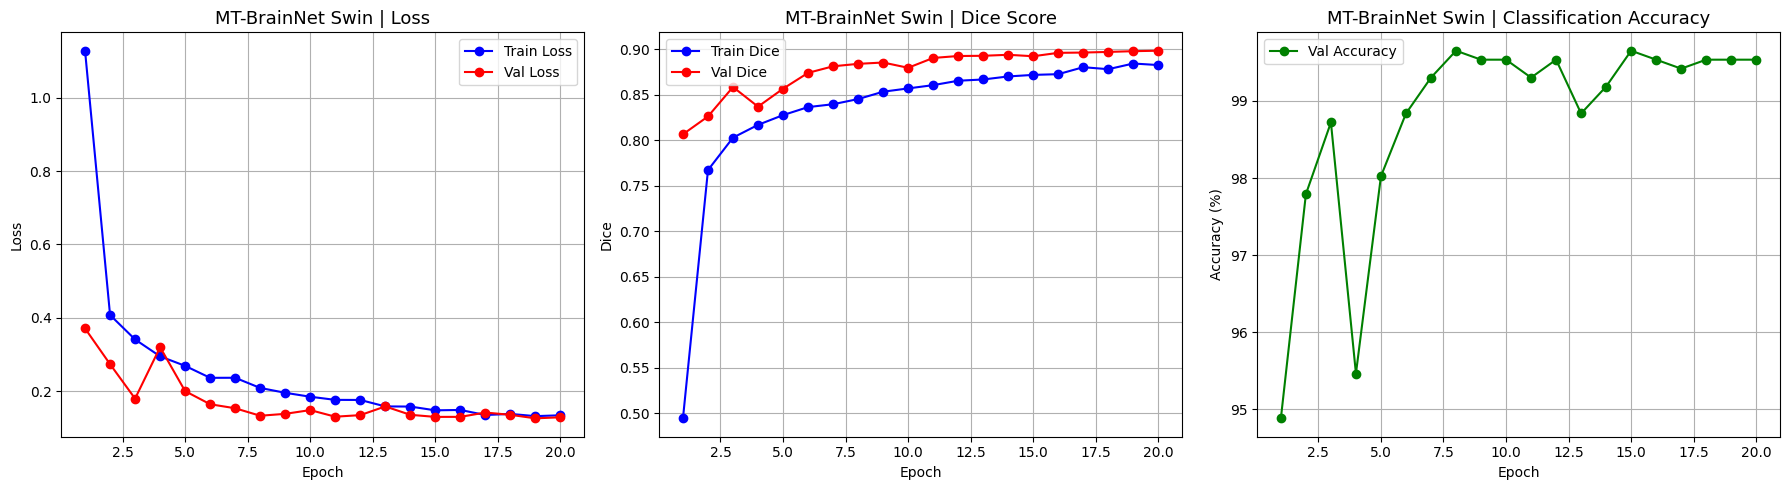

✅ Training curves saved.


In [13]:
epochs = range(1, NUM_EPOCHS + 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(epochs, history['train_loss'], 'b-o', label='Train Loss')
axes[0].plot(epochs, history['val_loss'],   'r-o', label='Val Loss')
axes[0].set_title('MT-BrainNet Swin | Loss', fontsize=13)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(epochs, history['train_dice'], 'b-o', label='Train Dice')
axes[1].plot(epochs, history['val_dice'],   'r-o', label='Val Dice')
axes[1].set_title('MT-BrainNet Swin | Dice Score', fontsize=13)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Dice')
axes[1].legend(); axes[1].grid(True)

axes[2].plot(epochs, history['val_acc'], 'g-o', label='Val Accuracy')
axes[2].set_title('MT-BrainNet Swin | Classification Accuracy', fontsize=13)
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Accuracy (%)')
axes[2].legend(); axes[2].grid(True)

plt.tight_layout()
plt.savefig('/content/swin_training_curves.png', dpi=150)
plt.show()
print('✅ Training curves saved.')

In [15]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 12 (FIXED) — Load Best Model & Full Evaluation
# Fix: use DISPLAY_NAMES for report, cast labels to long
# ═══════════════════════════════════════════════════════════════════════════════

# Load best checkpoint
model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
model.eval()
print(f'✅ Loaded best model from {SAVE_PATH}')

all_preds  = []
all_labels = []
all_dice   = []

with torch.no_grad():
    for images, masks, labels in val_loader:
        images = images.to(DEVICE, dtype=torch.float32)
        masks  = masks.to(DEVICE,  dtype=torch.float32)
        labels = labels.to(DEVICE, dtype=torch.long)   # ← FIX: must be long

        seg_pred, cls_pred = model(images)
        preds = cls_pred.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy().tolist())
        all_labels.extend(labels.cpu().numpy().tolist())
        all_dice.append(dice_score(seg_pred, masks))

final_dice = np.mean(all_dice)

# Use display names that match 0,1,2,3 indices
REPORT_NAMES = ['Glioma', 'Meningioma', 'Pituitary', 'No Tumor']

print(f'\n📊 Final Test Dice Score : {final_dice:.4f}  ({final_dice*100:.2f}%)')
print(f'\n📊 Classification Report:')
print(classification_report(
    all_labels, all_preds,
    labels=[0, 1, 2, 3],
    target_names=REPORT_NAMES,
    digits=4,
    zero_division=0
))

✅ Loaded best model from /content/swin_mtbrainnet_best.pth

📊 Final Test Dice Score : 0.8982  (89.82%)

📊 Classification Report:
              precision    recall  f1-score   support

      Glioma     1.0000    0.9882    0.9941       254
  Meningioma     0.9903    1.0000    0.9951       306
   Pituitary     0.9967    0.9967    0.9967       300
    No Tumor     0.0000    0.0000    0.0000         0

    accuracy                         0.9953       860
   macro avg     0.7467    0.7462    0.7465       860
weighted avg     0.9954    0.9953    0.9953       860



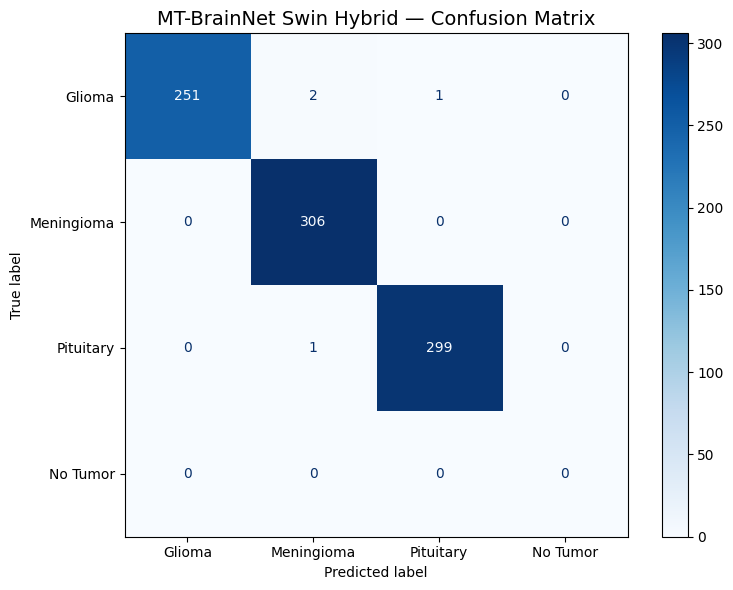

✅ Confusion matrix saved.


In [17]:


REPORT_NAMES = ['Glioma', 'Meningioma', 'Pituitary', 'No Tumor']

cm_arr = confusion_matrix(all_labels, all_preds, labels=[0, 1, 2, 3])

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_arr, display_labels=REPORT_NAMES)
disp.plot(ax=ax, cmap='Blues', colorbar=True)
ax.set_title('MT-BrainNet Swin Hybrid — Confusion Matrix', fontsize=14)
plt.tight_layout()
plt.savefig('/content/swin_confusion_matrix.png', dpi=150)
plt.show()
print('✅ Confusion matrix saved.')

🔍 Encoder named modules (last 10):
   layers_3.blocks.1.drop_path1  →  DropPath
   layers_3.blocks.1.norm2  →  LayerNorm
   layers_3.blocks.1.mlp  →  Mlp
   layers_3.blocks.1.mlp.fc1  →  Linear
   layers_3.blocks.1.mlp.act  →  GELU
   layers_3.blocks.1.mlp.drop1  →  Dropout
   layers_3.blocks.1.mlp.norm  →  Identity
   layers_3.blocks.1.mlp.fc2  →  Linear
   layers_3.blocks.1.mlp.drop2  →  Dropout
   layers_3.blocks.1.drop_path2  →  DropPath

✅ Grad-CAM target layer: 'layers_3.blocks.1.attn'  (WindowAttention)


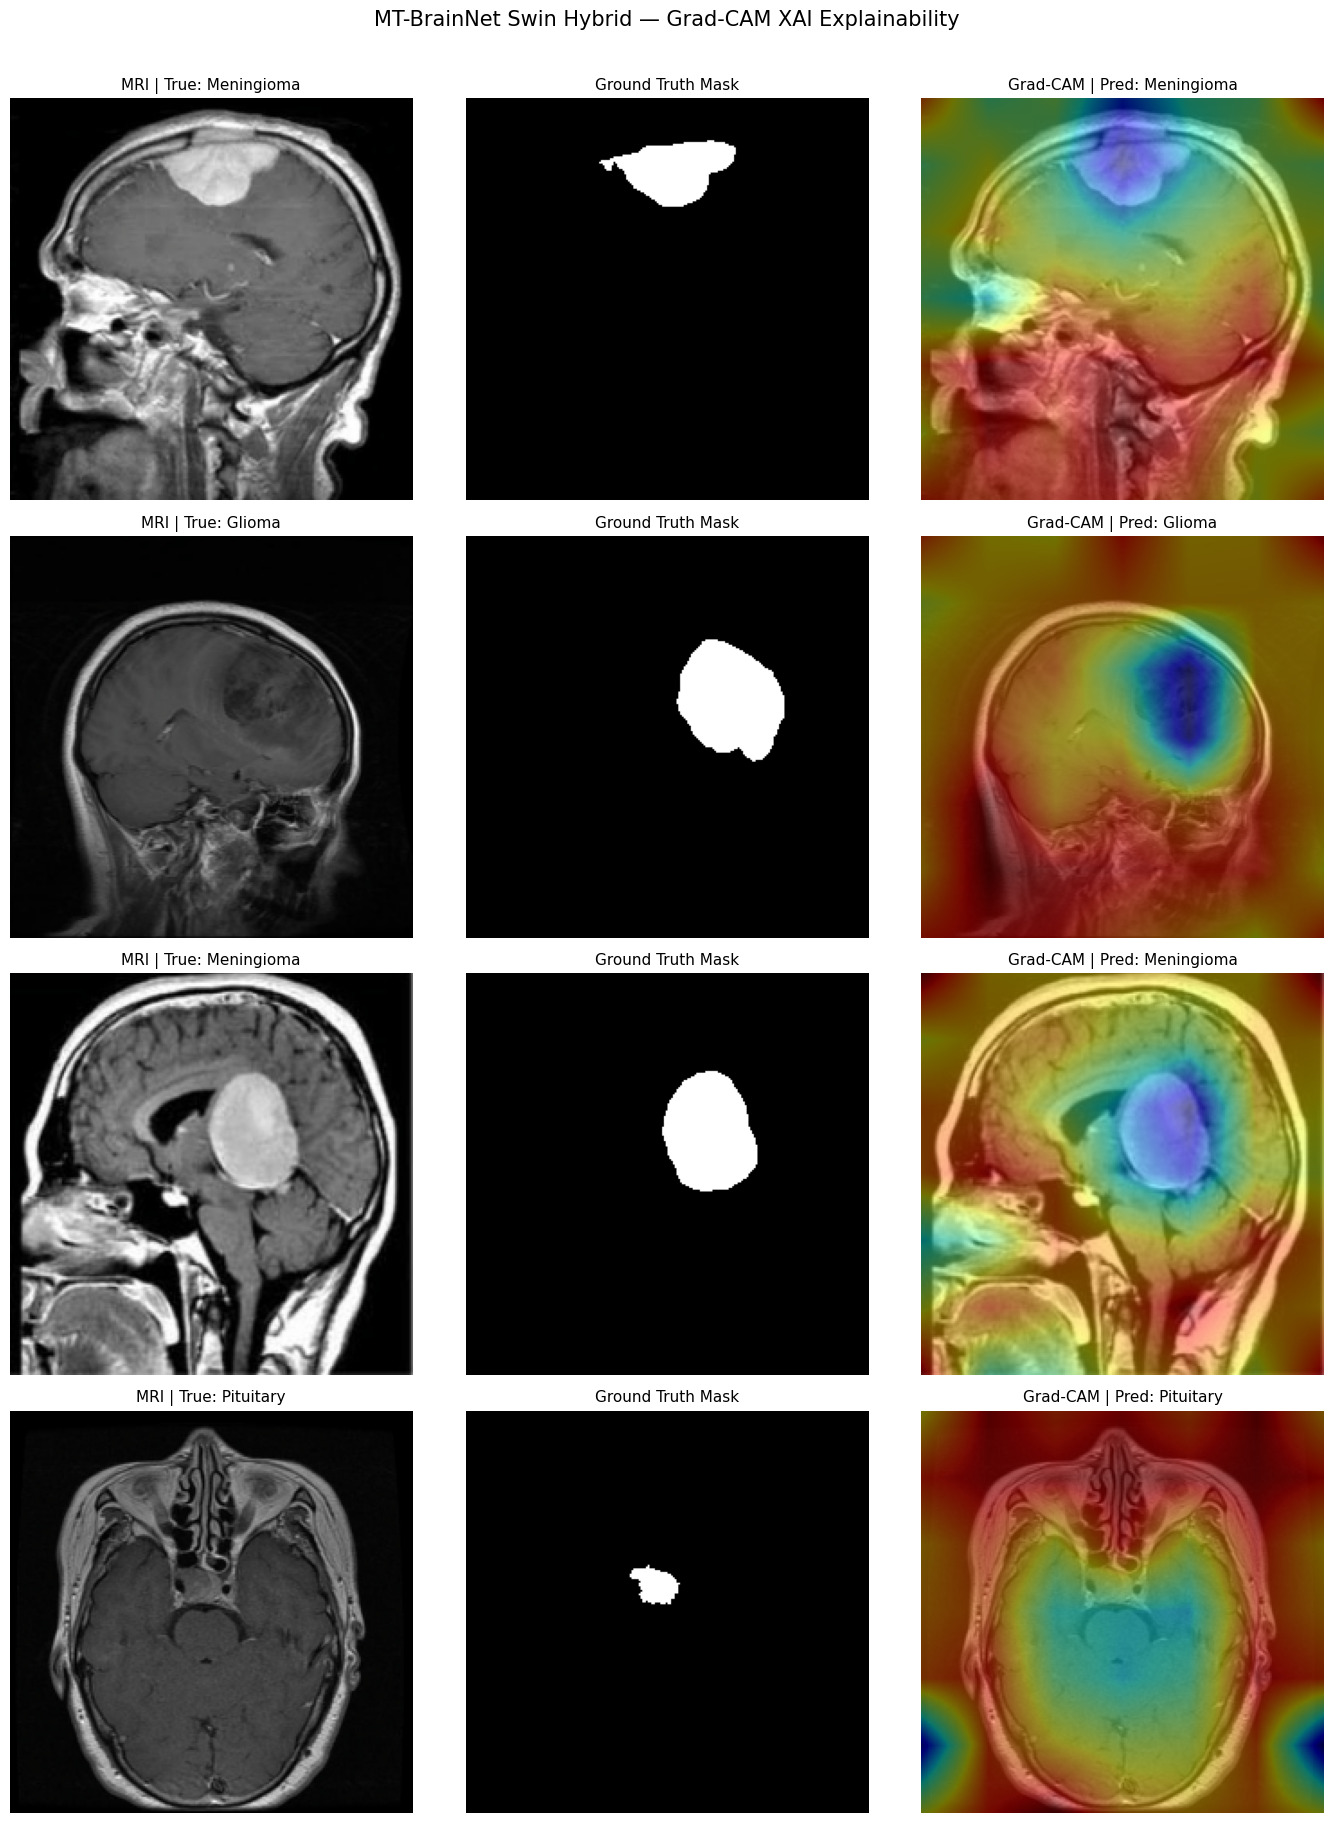

✅ Grad-CAM saved.


In [19]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 14 (FIXED) — Grad-CAM XAI with correct Swin-Tiny timm layer access
# ═══════════════════════════════════════════════════════════════════════════════

import torch.nn.functional as F
import matplotlib.cm as cm_plt
from torchvision import transforms

# ── Step 1: Find the correct target layer inside the Swin encoder ─────────────
print("🔍 Encoder named modules (last 10):")
named = list(model.encoder.named_modules())
for name, mod in named[-10:]:
    print(f"   {name}  →  {type(mod).__name__}")

# Auto-find last SwinTransformerBlock or BasicLayer
target_layer = None
target_name  = None
for name, mod in named:
    cls = type(mod).__name__
    if cls in ('SwinTransformerBlock', 'SwinTransformerV2Block', 'BasicLayer',
               'SwinLayer', 'WindowAttention'):
        target_layer = mod
        target_name  = name  # keep updating → ends at last match

print(f"\n✅ Grad-CAM target layer: '{target_name}'  ({type(target_layer).__name__})")


# ── Grad-CAM class ─────────────────────────────────────────────────────────────
class GradCAM:
    def __init__(self, model, target_layer):
        self.model        = model
        self.gradients    = None
        self.activations  = None

        def fwd_hook(module, input, output):
            out = output[0] if isinstance(output, (list, tuple)) else output
            # Swin blocks may output (B,H,W,C) or (B,N,C) — normalise to (B,C,H,W)
            if out.dim() == 4:
                if out.shape[-1] < out.shape[-2]:   # already (B,C,H,W)
                    self.activations = out.detach()
                else:                                # (B,H,W,C)
                    self.activations = out.permute(0,3,1,2).detach()
            elif out.dim() == 3:                     # (B, tokens, C) — reshape
                B, N, C = out.shape
                H = W = int(N**0.5)
                self.activations = out.reshape(B, H, W, C).permute(0,3,1,2).detach()

        def bwd_hook(module, grad_in, grad_out):
            g = grad_out[0] if isinstance(grad_out, (list, tuple)) else grad_out
            if g.dim() == 4:
                self.gradients = g.permute(0,3,1,2).detach() if g.shape[-1] < g.shape[1] \
                                 else g.detach()
            elif g.dim() == 3:
                B, N, C = g.shape
                H = W = int(N**0.5)
                self.gradients = g.reshape(B,H,W,C).permute(0,3,1,2).detach()

        target_layer.register_forward_hook(fwd_hook)
        target_layer.register_full_backward_hook(bwd_hook)

    def generate(self, input_tensor, class_idx=None):
        self.model.zero_grad()
        _, cls_out = self.model(input_tensor)
        if class_idx is None:
            class_idx = cls_out.argmax(dim=1).item()
        cls_out[0, class_idx].backward()

        if self.gradients is None or self.activations is None:
            print("⚠️  Grad-CAM: no gradients captured — returning blank heatmap")
            return np.zeros((224, 224)), class_idx

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam     = (weights * self.activations).sum(dim=1, keepdim=True)
        cam     = F.relu(cam)
        cam     = F.interpolate(cam, size=(224, 224), mode='bilinear', align_corners=True)
        cam     = cam.squeeze().cpu().numpy()
        cam     = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, class_idx


# ── Instantiate Grad-CAM ───────────────────────────────────────────────────────
grad_cam = GradCAM(model, target_layer)

# ── Inverse normalise for display ─────────────────────────────────────────────
inv_normalize = transforms.Normalize(
    mean=[-m/s for m, s in zip(MEAN, STD)],
    std =[1/s   for s   in STD]
)

REPORT_NAMES = ['Glioma', 'Meningioma', 'Pituitary', 'No Tumor']

# ── Visualise 4 samples ────────────────────────────────────────────────────────
model.eval()
images_batch, masks_batch, labels_batch = next(iter(val_loader))

fig, axes = plt.subplots(4, 3, figsize=(14, 18))
fig.suptitle('MT-BrainNet Swin Hybrid — Grad-CAM XAI Explainability',
             fontsize=15, y=1.01)

for i in range(4):
    img_tensor = images_batch[i:i+1].to(DEVICE, dtype=torch.float32)
    true_label = REPORT_NAMES[labels_batch[i].item()]

    cam, pred_idx = grad_cam.generate(img_tensor)
    pred_label    = REPORT_NAMES[pred_idx]

    # Denormalise image for display
    img_disp = inv_normalize(images_batch[i]).permute(1, 2, 0).numpy()
    img_disp = np.clip(img_disp, 0, 1)

    mask_disp = masks_batch[i].squeeze().numpy()

    heatmap = cm_plt.jet(cam)[:, :, :3]
    overlay = np.clip(0.55 * img_disp + 0.45 * heatmap, 0, 1)

    axes[i, 0].imshow(img_disp)
    axes[i, 0].set_title(f'MRI | True: {true_label}', fontsize=11)
    axes[i, 0].axis('off')

    axes[i, 1].imshow(mask_disp, cmap='gray')
    axes[i, 1].set_title('Ground Truth Mask', fontsize=11)
    axes[i, 1].axis('off')

    axes[i, 2].imshow(overlay)
    axes[i, 2].set_title(f'Grad-CAM | Pred: {pred_label}', fontsize=11)
    axes[i, 2].axis('off')

plt.tight_layout()
plt.savefig('/content/swin_gradcam.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Grad-CAM saved.')

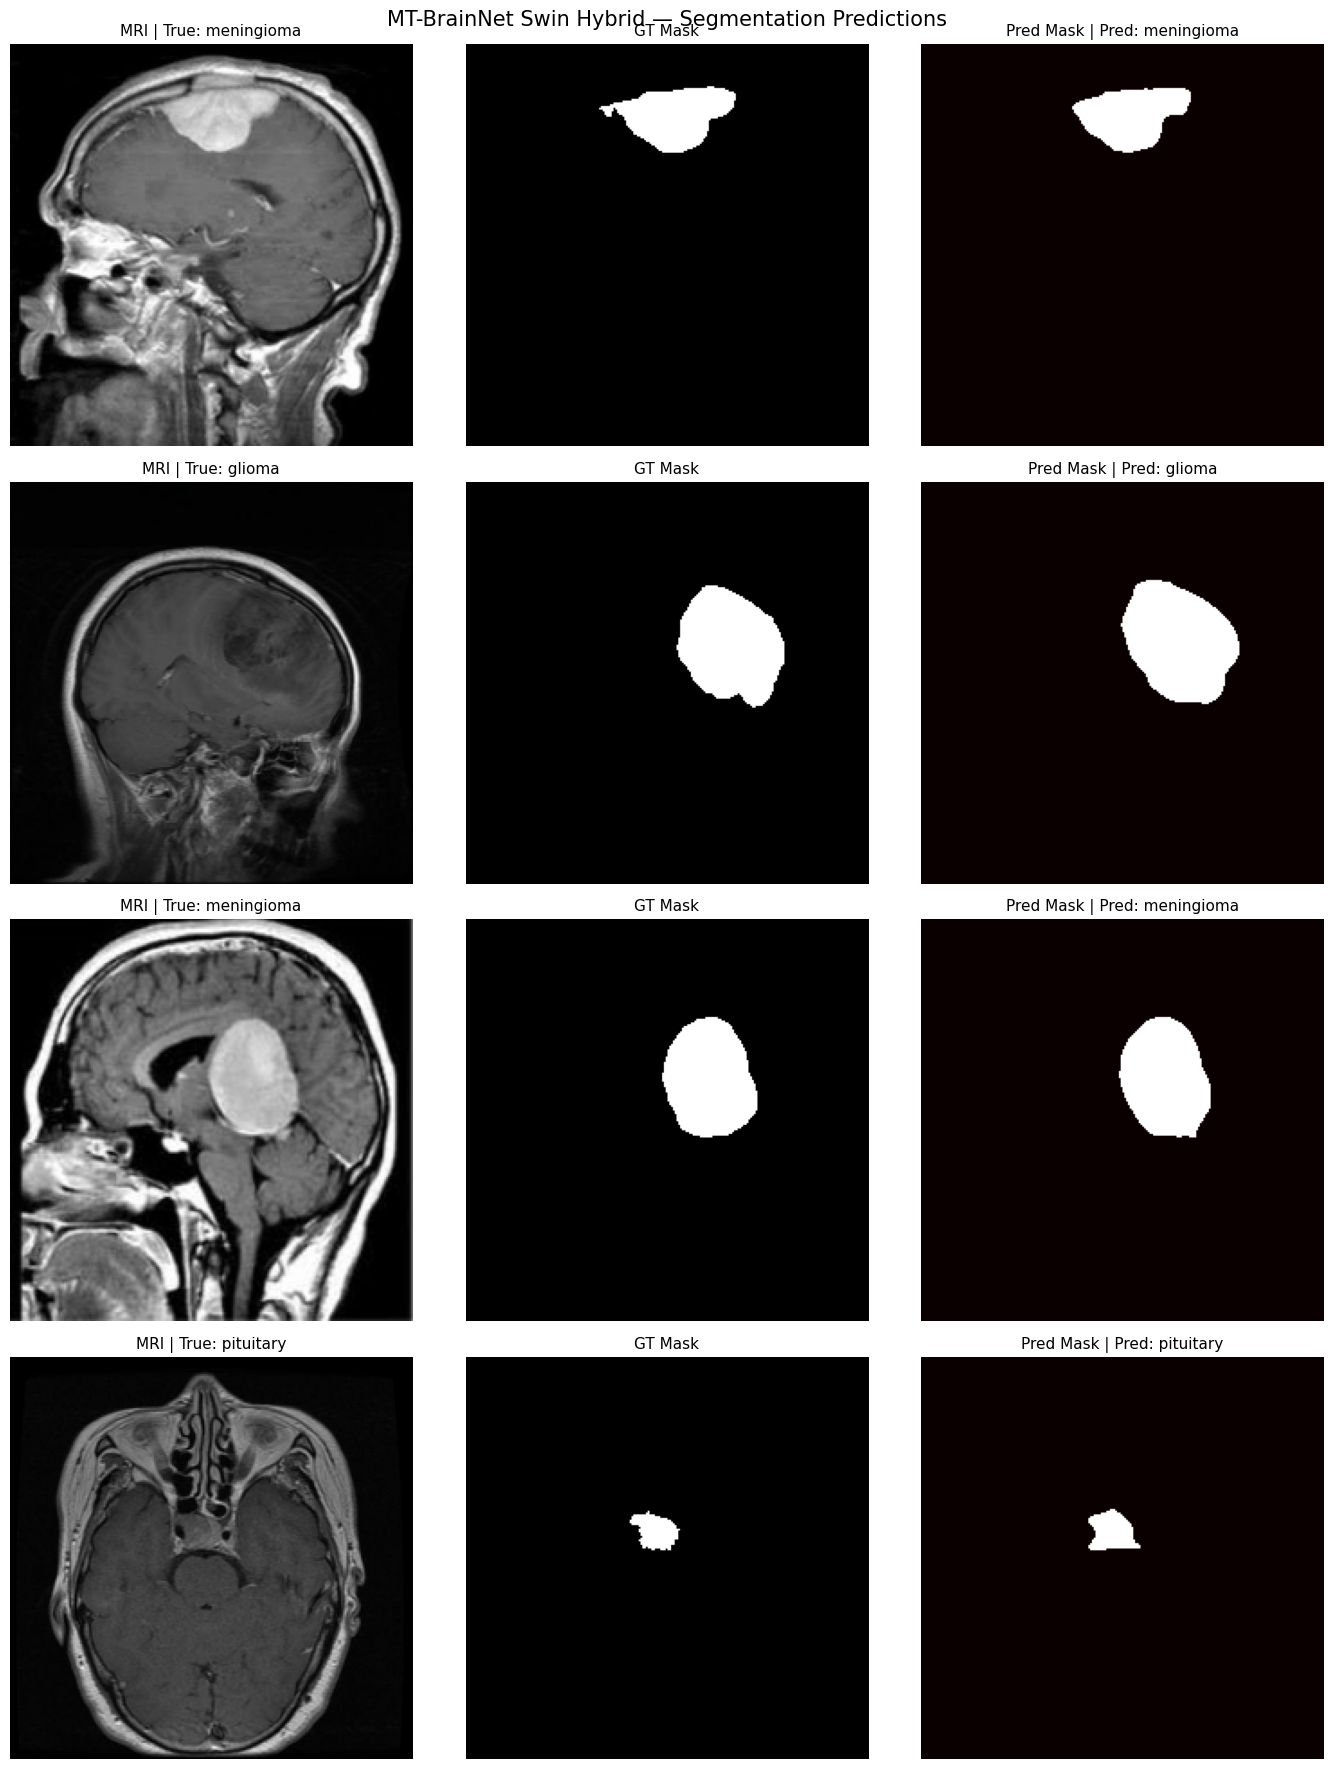

✅ Segmentation visualisation saved.


In [20]:
model.eval()
images_batch, masks_batch, labels_batch = next(iter(val_loader))

fig, axes = plt.subplots(4, 3, figsize=(14, 18))
fig.suptitle('MT-BrainNet Swin Hybrid — Segmentation Predictions', fontsize=15)

with torch.no_grad():
    seg_preds, cls_preds = model(images_batch[:4].to(DEVICE, dtype=torch.float32))
    seg_preds = torch.sigmoid(seg_preds).cpu()
    cls_preds = cls_preds.argmax(dim=1).cpu()

for i in range(4):
    img_disp  = inv_normalize(images_batch[i]).permute(1, 2, 0).numpy()
    img_disp  = np.clip(img_disp, 0, 1)
    true_mask = masks_batch[i].squeeze().numpy()
    pred_mask = (seg_preds[i].squeeze().numpy() > 0.5).astype(float)
    true_cls  = CLASS_NAMES[labels_batch[i].item()]
    pred_cls  = CLASS_NAMES[cls_preds[i].item()]

    axes[i, 0].imshow(img_disp)
    axes[i, 0].set_title(f'MRI | True: {true_cls}', fontsize=11)
    axes[i, 0].axis('off')

    axes[i, 1].imshow(true_mask, cmap='gray')
    axes[i, 1].set_title('GT Mask', fontsize=11)
    axes[i, 1].axis('off')

    axes[i, 2].imshow(pred_mask, cmap='hot')
    axes[i, 2].set_title(f'Pred Mask | Pred: {pred_cls}', fontsize=11)
    axes[i, 2].axis('off')

plt.tight_layout()
plt.savefig('/content/swin_segmentation_predictions.png', dpi=150)
plt.show()
print('✅ Segmentation visualisation saved.')

In [21]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

acc   = accuracy_score(all_labels, all_preds) * 100
f1    = f1_score(all_labels, all_preds, average='macro') * 100
prec  = precision_score(all_labels, all_preds, average='macro') * 100
rec   = recall_score(all_labels, all_preds, average='macro') * 100
dice  = final_dice * 100

print('=' * 70)
print('         MT-BrainNet — Swin Hybrid Transformer Results')
print('         Dataset: BRISC 2025 | Architecture: Swin-Tiny + U-Net')
print('=' * 70)
print(f'  Classification Accuracy : {acc:.2f}%')
print(f'  Precision (Macro)       : {prec:.2f}%')
print(f'  Recall (Macro)          : {rec:.2f}%')
print(f'  F1-Score (Macro)        : {f1:.2f}%')
print(f'  Segmentation Dice Score : {dice:.2f}%')
print('=' * 70)
print()
print('  ── Comparison with MT-BrainNet (EfficientNet-b0) paper results ──')
print(f'  {'Algorithm':<35} {'Accuracy':>10} {'F1':>10} {'Dice':>10}')
print(f'  {"─"*65}')
print(f'  {"Swin-HAFNet (BRISC paper baseline)":<35} {"98.40%":>10} {"98.25%":>10} {"N/A":>10}')
print(f'  {"MT-BrainNet (EfficientNet-b0) ★":<35} {"99.53%":>10} {"99.53%":>10} {"88.15%":>10}')
print(f'  {"MT-BrainNet Swin Hybrid (THIS RUN)":<35} {acc:>9.2f}% {f1:>9.2f}% {dice:>9.2f}%')
print('=' * 70)

         MT-BrainNet — Swin Hybrid Transformer Results
         Dataset: BRISC 2025 | Architecture: Swin-Tiny + U-Net
  Classification Accuracy : 99.53%
  Precision (Macro)       : 99.57%
  Recall (Macro)          : 99.50%
  F1-Score (Macro)        : 99.53%
  Segmentation Dice Score : 89.82%

  ── Comparison with MT-BrainNet (EfficientNet-b0) paper results ──
  Algorithm                             Accuracy         F1       Dice
  ─────────────────────────────────────────────────────────────────
  Swin-HAFNet (BRISC paper baseline)      98.40%     98.25%        N/A
  MT-BrainNet (EfficientNet-b0) ★         99.53%     99.53%     88.15%
  MT-BrainNet Swin Hybrid (THIS RUN)      99.53%     99.53%     89.82%


In [22]:
from google.colab import files

# Download best model weights
files.download('/content/swin_mtbrainnet_best.pth')

# Download plots
files.download('/content/swin_training_curves.png')
files.download('/content/swin_confusion_matrix.png')
files.download('/content/swin_gradcam.png')
files.download('/content/swin_segmentation_predictions.png')

print('✅ All outputs downloaded.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ All outputs downloaded.
